In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the raw dataset generated earlier
df = pd.read_csv('fertilizer_lab_raw_data.csv')

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print("Dataset Overview:")
display(df.head())
print(f"Total Logged Tests: {df.shape[0]}")

Dataset Overview:


,Timestamp,Shift,Analyst_ID,Urea_Biuret_Pct,Urea_Moisture_Pct,Urea_Prill_Size_Pct,Ammonia_Purity_Pct,Boiler_Water_pH
0,2025-01-01,Morning,AN-04,0.790,0.216,94.86,99.852,8.94
1,2025-01-01,Evening,AN-02,0.731,0.193,92.63,99.652,9.04
2,2025-01-01,Night,AN-03,0.704,0.204,92.30,99.608,8.35
3,2025-01-02,Morning,AN-04,0.826,0.204,93.25,99.722,8.81
4,2025-01-02,Evening,AN-03,0.706,0.223,91.08,99.738,8.85


Total Logged Tests: 1095


In [3]:
# Biuret Specification
USL_biuret = 1.00  # Upper Specification Limit (%)
mean_biuret = df['Urea_Biuret_Pct'].mean()
std_biuret = df['Urea_Biuret_Pct'].std()

# Cpk Calculation for Upper Limit
cpk_biuret = (USL_biuret - mean_biuret) / (3 * std_biuret)

print(f"--- Urea Biuret Process Capability Analysis ---")
print(f"Mean Biuret Content: {mean_biuret:.4f}%")
print(f"Standard Deviation (σ): {std_biuret:.4f}%")
print(f"Upper Specification Limit (USL): {USL_biuret}%")
print(f"Calculated Cpk Index: {cpk_biuret:.3f}")

if cpk_biuret >= 1.33:
    print("Process Status: STABLE & CAPABLE")
elif cpk_biuret >= 1.0:
    print("Process Status: MARGINALLY CAPABLE (Requires Monitoring)")
else:
    print("Process Status: NOT CAPABLE (High risk of Out-Of-Specification batches)")

--- Urea Biuret Process Capability Analysis ---
Mean Biuret Content: 0.7552%
Standard Deviation (σ): 0.0858%
Upper Specification Limit (USL): 1.0%
Calculated Cpk Index: 0.951
Process Status: NOT CAPABLE (High risk of Out-Of-Specification batches)


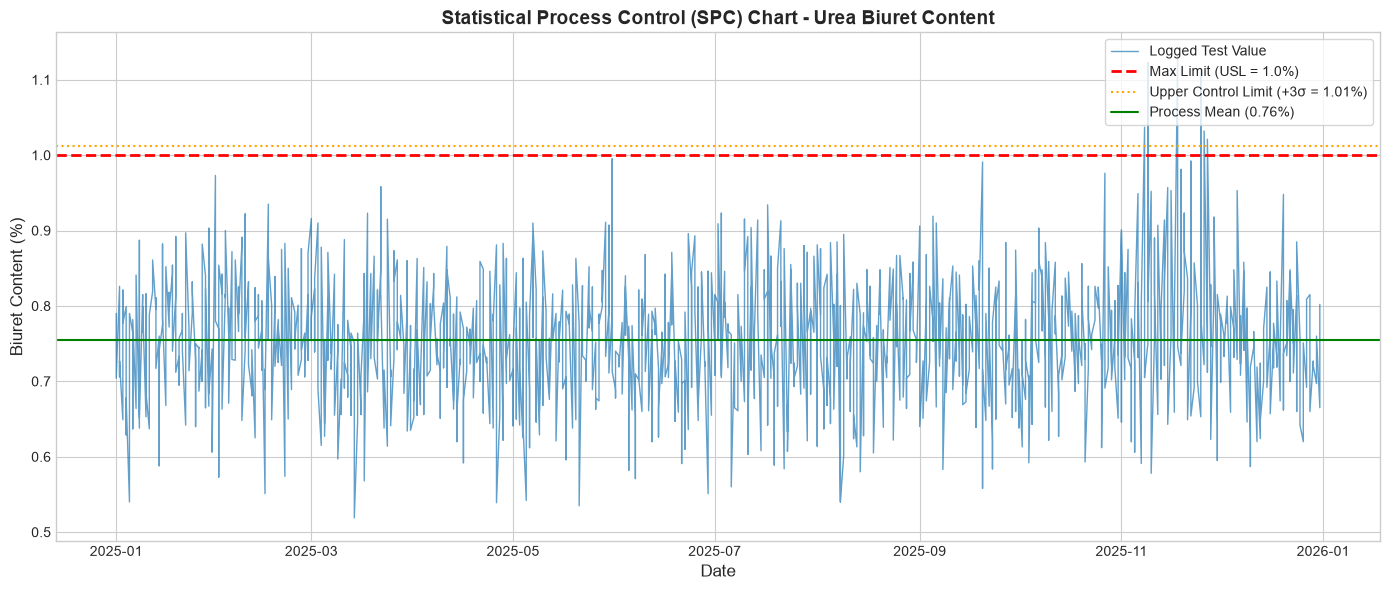

In [4]:
# Calculate control limits (3-Sigma)
ucl_3sigma = mean_biuret + (3 * std_biuret)
lcl_3sigma = max(0, mean_biuret - (3 * std_biuret))

fig, ax = plt.subplots(figsize=(14, 6))

# Plot Biuret trend line
ax.plot(df['Timestamp'], df['Urea_Biuret_Pct'], color='#1f77b4', alpha=0.7, linewidth=1, label='Logged Test Value')

# Reference lines
ax.axhline(USL_biuret, color='red', linestyle='--', linewidth=2, label=f'Max Limit (USL = {USL_biuret}%)')
ax.axhline(ucl_3sigma, color='orange', linestyle=':', linewidth=1.5, label=f'Upper Control Limit (+3σ = {ucl_3sigma:.2f}%)')
ax.axhline(mean_biuret, color='green', linestyle='-', linewidth=1.5, label=f'Process Mean ({mean_biuret:.2f}%)')

# Formatting
ax.set_title('Statistical Process Control (SPC) Chart - Urea Biuret Content', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Biuret Content (%)', fontsize=12)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('biuret_spc_chart.png', dpi=300)
plt.show()

In [5]:
# Flag Out-Of-Specification (OOS) batches
df['Biuret_OOS'] = df['Urea_Biuret_Pct'] > 1.00
df['Moisture_OOS'] = df['Urea_Moisture_Pct'] > 0.30
df['Prill_OOS'] = df['Urea_Prill_Size_Pct'] < 90.00
df['Ammonia_OOS'] = df['Ammonia_Purity_Pct'] < 99.50
df['Water_pH_OOS'] = (df['Boiler_Water_pH'] < 8.5) | (df['Boiler_Water_pH'] > 9.5)

# Overall Pass/Fail Status
df['Batch_Status'] = np.where(
    df[['Biuret_OOS', 'Moisture_OOS', 'Prill_OOS', 'Ammonia_OOS', 'Water_pH_OOS']].any(axis=1),
    'FAIL',
    'PASS'
)

# Export enriched dataset for Power BI ingestion
df.to_csv('lims_processed_powerbi_data.csv', index=False)

print("Export Complete!")
print(f"Total Passed Batches: {(df['Batch_Status'] == 'PASS').sum()}")
print(f"Total Failed Batches: {(df['Batch_Status'] == 'FAIL').sum()}")

Export Complete!
Total Passed Batches: 895
Total Failed Batches: 200
